# Vision par ordinateur et traitement du signal pour la surveillance de patients — preuve de concept

**Projet de portfolio technique —**
Auteur : Dini Ahamada

## Objectif

Ce projet illustre, à travers deux cas d'usage indépendants, comment des méthodes d'IA peuvent transformer des données brutes (vidéo, signal électrophysiologique) en indicateurs cliniquement interprétables

- **Partie A — Vision par ordinateur** : suivi de points-clés corporels sur vidéo pour quantifier le
  mouvement/l'agitation d'une personne, par analogie méthodologique avec l'évaluation de la motilité
  et de l'agitation des patients à partir de vidéos RVB-D en soins intensifs.
- **Partie B — Traitement du signal** : filtrage, détection de pics et classification de battements
  cardiaques à partir d'un signal ECG, par analogie avec le traitement des signes vitaux mesurés en
  continu en soins intensifs.

> **Note de positionnement** : ce projet utilise une vidéo générique (non clinique) et un jeu de données ECG public — il s'agit d'une **démonstration
> méthodologique transposable**, et non d'un travail sur des données patients réelles, auxquelles
> l'accès nécessite une accréditation clinique et éthique que ce prototype n'a pas vocation à
> contourner.


## Partie A — Vision par ordinateur : quantification du mouvement/agitation

In [1]:
# Bibliothèques nécessaires
!pip install mediapipe --quiet

# Modèle officiel MediaPipe Pose Landmarker (API Tasks — remplace l'ancienne API 'solutions',
# dépréciée par Google et responsable de l'erreur "module 'mediapipe' has no attribute 'solutions'")
!wget -q -O pose_landmarker.task https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task
print("Modèle téléchargé.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 6.0 MB/s eta 0:00:00
Modèle téléchargé.


### A.1 — Charger une vidéo

Enregistre une courte vidéo (10-20 secondes) de toi en train de bouger (te lever, agiter les bras,
marcher sur place) avec ton téléphone ou ta webcam, exporte-la en .mp4, puis téléverse-la ci-dessous.
Ceci sert uniquement de preuve de concept méthodologique — aucune donnée clinique n'est utilisée.

In [11]:
from google.colab import files

print("Téléverse ta vidéo (man_walking.mp4) :")
uploaded = files.upload()
video_path = list(uploaded.keys())[0]
print("Fichier chargé :", video_path)


Téléverse ta vidéo (man_walking.mp4) :


Saving man_walking.mp4 to man_walking.mp4
Fichier chargé : man_walking.mp4


### A.2 — Suivi des points-clés corporels (MediaPipe Pose)

Pour chaque image de la vidéo, on détecte 33 points-clés du corps (épaules, coudes, hanches, genoux,
etc.). On calcule ensuite, pour chaque image, le déplacement moyen des points-clés par rapport à
l'image précédente — c'est notre indicateur d'agitation/motilité, directement inspiré des mesures
utilisées en surveillance vidéo de patients.

In [12]:
import cv2
import mediapipe as mp
import numpy as np
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

# Configuration du détecteur de pose (API Tasks, mode vidéo)
base_options = mp_python.BaseOptions(model_asset_path="pose_landmarker.task")
options = mp_vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=mp_vision.RunningMode.VIDEO,
)
landmarker = mp_vision.PoseLandmarker.create_from_options(options)

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS) or 30

landmarks_over_time = []
sample_frame_with_skeleton = None
frame_idx = 0

while cap.isOpened():
    ok, frame = cap.read()
    if not ok:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    timestamp_ms = int(frame_idx * (1000 / fps))
    result = landmarker.detect_for_video(mp_image, timestamp_ms)

    if result.pose_landmarks:
        coords = np.array([[lm.x, lm.y] for lm in result.pose_landmarks[0]])
        landmarks_over_time.append(coords)

        # garder une image (vers le milieu de la vidéo) avec les points-clés dessinés, pour illustration
        if sample_frame_with_skeleton is None and frame_idx > 10:
            annotated = frame.copy()
            h, w, _ = annotated.shape
            for x, y in coords:
                cv2.circle(annotated, (int(x * w), int(y * h)), 4, (0, 255, 0), -1)
            sample_frame_with_skeleton = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    else:
        landmarks_over_time.append(None)

    frame_idx += 1

cap.release()
landmarker.close()
print(f"Images traitées : {frame_idx} | Images avec détection : {sum(l is not None for l in landmarks_over_time)}")


Images traitées : 1167 | Images avec détection : 1166


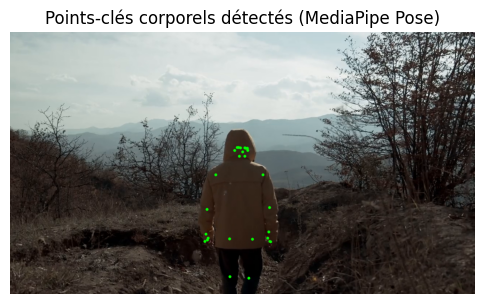

In [13]:
import matplotlib.pyplot as plt

# Image d'exemple avec le squelette superposé
plt.figure(figsize=(6, 6))
plt.imshow(sample_frame_with_skeleton)
plt.axis('off')
plt.title("Points-clés corporels détectés (MediaPipe Pose)")
plt.show()


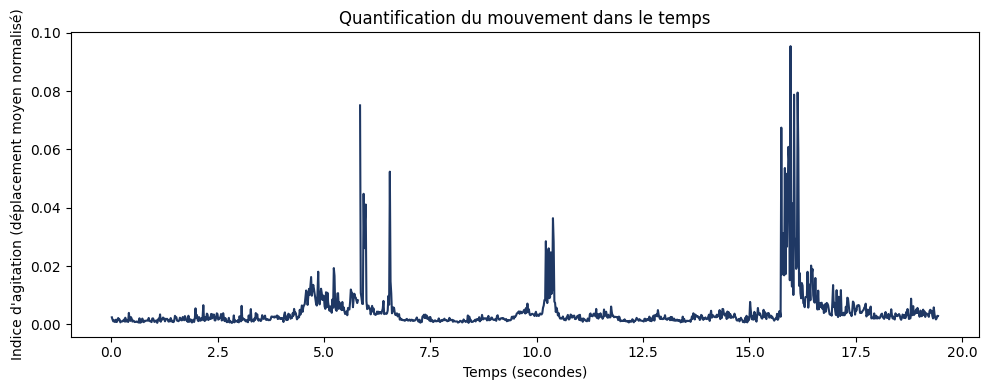

Indice d'agitation moyen sur la séquence : 0.0044


In [14]:
# Calcul de l'indice d'agitation : déplacement moyen des points-clés entre deux images consécutives
agitation_index = [np.nan]  # pas de valeur pour la première image

for i in range(1, len(landmarks_over_time)):
    prev, curr = landmarks_over_time[i - 1], landmarks_over_time[i]
    if prev is not None and curr is not None:
        displacement = np.linalg.norm(curr - prev, axis=1).mean()
        agitation_index.append(displacement)
    else:
        agitation_index.append(np.nan)

time_seconds = np.arange(len(agitation_index)) / fps

plt.figure(figsize=(10, 4))
plt.plot(time_seconds, agitation_index, color="#1F3864")
plt.xlabel("Temps (secondes)")
plt.ylabel("Indice d'agitation (déplacement moyen normalisé)")
plt.title("Quantification du mouvement dans le temps")
plt.tight_layout()
plt.show()

print("Indice d'agitation moyen sur la séquence :", round(np.nanmean(agitation_index), 4))


**Transposition au contexte clinique** : la même approche — extraction de points-clés puis calcul
d'un indicateur de mouvement dans le temps — s'applique directement à des vidéos RVB-D ou infrarouges
de patients en soins intensifs, pour quantifier automatiquement la motilité ou l'agitation, l'un des
signaux mentionnés dans l'annonce du projet. Les données infrarouges/profondeur ajoutent une robustesse
à l'éclairage variable (utile la nuit), mais le principe de traitement reste le même.

## Partie B — Traitement du signal : analyse d'un signal ECG

On utilise le jeu de données ouvert **MIT-BIH Arrhythmia Database** (PhysioNet), en accès libre,
sans accréditation requise, via la bibliothèque `wfdb` qui permet de lire les enregistrements
directement depuis le serveur de PhysioNet.

In [6]:
!pip install wfdb --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 94.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.


### B.1 — Chargement et filtrage d'un signal ECG

In [7]:
import wfdb
from scipy.signal import butter, filtfilt, find_peaks

record_name = "100"  # enregistrement de référence de la base MIT-BIH
record = wfdb.rdrecord(record_name, pn_dir="mitdb")
annotation = wfdb.rdann(record_name, "atr", pn_dir="mitdb")

signal = record.p_signal[:, 0]   # dérivation MLII
fs = record.fs                    # fréquence d'échantillonnage (Hz)
print(f"Signal chargé : {len(signal)} échantillons à {fs} Hz ({len(signal)/fs:.0f} secondes)")

# Filtre passe-bande (0.5 - 40 Hz) pour éliminer la dérive de ligne de base et le bruit haute fréquence
def bandpass_filter(sig, fs, low=0.5, high=40, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, sig)

filtered_signal = bandpass_filter(signal, fs)


Signal chargé : 650000 échantillons à 360 Hz (1806 secondes)


### B.2 — Détection automatique des pics R

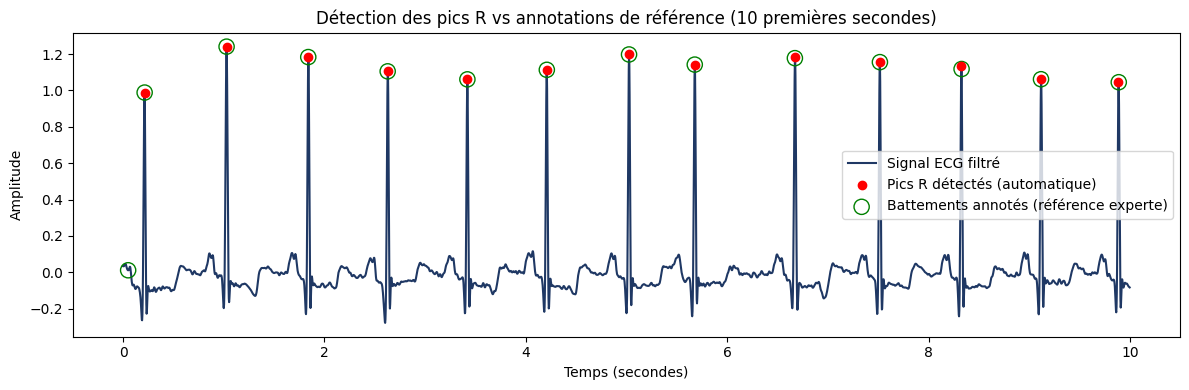

Pics détectés automatiquement : 2277 | Battements annotés (tout l'enregistrement) : 2274


In [8]:
# Détection des pics R par recherche de maxima locaux, avec contraintes de hauteur et de distance minimale
min_distance = int(0.25 * fs)  # deux battements ne peuvent pas être à moins de 250 ms l'un de l'autre
detected_peaks, _ = find_peaks(filtered_signal, height=np.mean(filtered_signal) + 0.5 * np.std(filtered_signal),
                                distance=min_distance)

# Comparaison visuelle sur une fenêtre de 10 secondes avec les annotations expertes de PhysioNet
window = slice(0, 10 * fs)
ann_in_window = annotation.sample[annotation.sample < 10 * fs]

plt.figure(figsize=(12, 4))
plt.plot(np.arange(10 * fs) / fs, filtered_signal[window], label="Signal ECG filtré", color="#1F3864")
plt.scatter(detected_peaks[detected_peaks < 10 * fs] / fs, filtered_signal[detected_peaks[detected_peaks < 10 * fs]],
            color="red", label="Pics R détectés (automatique)", zorder=5)
plt.scatter(ann_in_window / fs, filtered_signal[ann_in_window], facecolors='none', edgecolors='green',
            s=120, label="Battements annotés (référence experte)", zorder=4)
plt.xlabel("Temps (secondes)")
plt.ylabel("Amplitude")
plt.title("Détection des pics R vs annotations de référence (10 premières secondes)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Pics détectés automatiquement : {len(detected_peaks)} | Battements annotés (tout l'enregistrement) : {len(annotation.sample)}")


### B.3 — Classification des battements (normal vs anormal)

Pour l'étape de classification, on s'appuie sur les annotations expertes de PhysioNet (fiables et
utilisées comme référence dans la littérature) plutôt que sur la détection automatique ci-dessus, afin
d'entraîner un modèle sur des étiquettes de qualité. On combine plusieurs enregistrements pour obtenir
un jeu de données suffisant.

In [9]:
NORMAL_SYMBOLS = {"N", "L", "R"}
BEAT_SYMBOLS = {"N","L","R","B","A","a","J","S","V","r","F","e","j","n","E","/","f","Q"}

def extract_beat_features(record_name):
    rec = wfdb.rdrecord(record_name, pn_dir="mitdb")
    ann = wfdb.rdann(record_name, "atr", pn_dir="mitdb")
    sig = bandpass_filter(rec.p_signal[:, 0], rec.fs)

    rows = []
    samples, symbols = ann.sample, ann.symbol
    for i in range(1, len(samples) - 1):
        if symbols[i] not in BEAT_SYMBOLS:
            continue
        rr_prev = (samples[i] - samples[i - 1]) / rec.fs
        rr_next = (samples[i + 1] - samples[i]) / rec.fs
        amplitude = sig[samples[i]]
        local_std = sig[max(0, samples[i] - 20): samples[i] + 20].std()
        label = 0 if symbols[i] in NORMAL_SYMBOLS else 1
        rows.append([rr_prev, rr_next, amplitude, local_std, label])
    return rows

records_to_use = ["100", "101", "103", "105", "106", "116", "119", "200"]
all_rows = []
for rec_name in records_to_use:
    all_rows.extend(extract_beat_features(rec_name))
    print(f"Enregistrement {rec_name} traité — total cumulé : {len(all_rows)} battements")

import pandas as pd
beats_df = pd.DataFrame(all_rows, columns=["rr_prev", "rr_next", "amplitude", "local_std", "label"])
print("\nRépartition des classes :")
print(beats_df['label'].value_counts().rename({0: "Normal", 1: "Anormal"}))


Enregistrement 100 traité — total cumulé : 2272 battements
Enregistrement 101 traité — total cumulé : 4136 battements
Enregistrement 103 traité — total cumulé : 6219 battements
Enregistrement 105 traité — total cumulé : 8790 battements
Enregistrement 106 traité — total cumulé : 10816 battements
Enregistrement 116 traité — total cumulé : 13227 battements
Enregistrement 119 traité — total cumulé : 15213 battements
Enregistrement 200 traité — total cumulé : 17813 battements

Répartition des classes :
label
Normal     15794
Anormal     2019
Name: count, dtype: int64


AUROC : 0.999
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00      3949
     Anormal       0.96      0.98      0.97       505

    accuracy                           0.99      4454
   macro avg       0.98      0.99      0.98      4454
weighted avg       0.99      0.99      0.99      4454



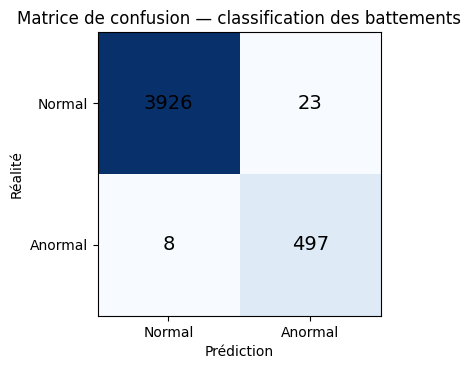

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

X = beats_df.drop(columns=["label"])
y = beats_df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
preds = clf.predict(X_test)

print("AUROC :", round(roc_auc_score(y_test, proba), 3))
print(classification_report(y_test, preds, target_names=["Normal", "Anormal"]))

cm = confusion_matrix(y_test, preds)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Normal", "Anormal"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Normal", "Anormal"])
ax.set_xlabel("Prédiction"); ax.set_ylabel("Réalité")
ax.set_title("Matrice de confusion — classification des battements")
plt.tight_layout()
plt.show()


## Conclusion et limites

Ce prototype démontre, en complément du premier projet (prédiction du risque avec explicabilité SHAP),
deux compétences techniques directement demandées dans l'annonce du projet doctoral :

- **Vision par ordinateur** : extraction de points-clés corporels et quantification du mouvement à
  partir de vidéo, transposable à l'évaluation de la motilité/agitation de patients.
- **Traitement du signal** : filtrage, détection automatique de pics et classification de battements
  cardiaques à partir d'un signal physiologique réel.

**Limites assumées** :
- La vidéo utilisée en partie A est générique (non clinique) et le contexte d'éclairage/caméra est
  très différent d'un environnement de soins intensifs réel (caméras RVB-D/infrarouges fixes).
- Le signal ECG (partie B) provient d'une base ambulatoire standard, pas d'un contexte de soins
  intensifs pédiatriques — les caractéristiques du signal (bruit, artéfacts de mouvement, contexte
  clinique) y diffèrent sensiblement.
- Les deux approches restent volontairement simples (RandomForest, filtrage classique) plutôt que des
  architectures profondes spécialisées (CNN 3D, réseaux récurrents), par souci de réalisation dans un
  délai court — des pistes explicites pour des travaux futurs.
